# Day 2 · 区域毛利率诊断 · 海豚生 🐬

> **德邦经营方向 · 第 2 天练习**  
> 目标：按区域分组，找出「营收高但毛利率低」的拖后腿区域

---

## 今天你要学会

| 技能 | 对应德邦场景 |
|------|-------------|
| `df.groupby("region")` | 按大区/网点汇总 |
| `.agg()` 多指标聚合 | 一次算营收、单量、毛利 |
| `.sort_values()` 排序 | 找 TOP 区域、找最差区域 |
| 经营结论 | 从数字到「该干什么」 |

## 对标案例

先理解思路：打开 `假如你是某连锁超市的数据分析师.ipynb`（按**门店**分组）  
今天换成按 **region（区域）** 分组，逻辑一模一样。

**文件名：** `Day2_Region_Analysis.ipynb`（就在同一文件夹里）

In [1]:
import pandas as pd

df = pd.read_csv("data/orders.csv")
df["毛利"] = df["revenue"] - df["cost"]

print(f"数据加载完成：{len(df)} 条运单，{df['region'].nunique()} 个区域")
df[["order_id", "region", "revenue", "cost", "毛利"]].head(3)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\32669\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\32669\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\32669\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\32669\anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Users\32669\anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

数据加载完成：150 条运单，5 个区域


,order_id,region,revenue,cost,毛利
0,ORD2024110001,华东,212.79,170.13,42.66
1,ORD2025010002,西南,2985.46,2444.20,541.26
2,ORD2024020003,华北,2205.41,1571.92,633.49


---
## 第 1 步：按区域汇总（核心技能 ⭐）

**Excel 做法：** 数据透视表，行=区域，值=求和(营收)、计数(单量)  
**Pandas 做法：** `groupby` + `agg`

In [2]:
# 按 region 分组，一次算出多个指标
region_stats = df.groupby("region").agg(
    总营收=("revenue", "sum"),
    总单量=("order_id", "count"),
    总毛利=("毛利", "sum"),
).reset_index()

# 新增：毛利率
region_stats["毛利率(%)"] = (region_stats["总毛利"] / region_stats["总营收"] * 100).round(2)

# 按营收从高到低排序
region_stats = region_stats.sort_values("总营收", ascending=False)
region_stats

,region,总营收,总单量,总毛利,毛利率(%)
1,华中,97965.64,30,27202.93,27.77
4,西南,83439.89,33,21928.79,26.28
3,华南,68844.94,35,18650.41,27.09
0,华东,44573.84,29,12079.20,27.10
2,华北,33173.30,23,9618.90,29.00


---
## 第 2 步：找出「问题区域」

经营上要盯两种区域：

1. **营收 TOP 1** → 基本盘，要守住  
2. **毛利率最低** → 可能在「赚流水不赚利润」，要重点排查

德邦常见毛利率基准线：**25%**

In [3]:
BENCHMARK = 25.0  # 毛利率基准线(%)

top_revenue = region_stats.iloc[0]
worst_margin = region_stats.sort_values("毛利率(%)").iloc[0]
below_benchmark = region_stats[region_stats["毛利率(%)"] < BENCHMARK]

print("=" * 45)
print("  区域经营诊断 · 海豚生")
print("=" * 45)
print(f"  营收冠军: {top_revenue['region']}区")
print(f"           营收 {top_revenue['总营收']:,.0f} 元 | 毛利率 {top_revenue['毛利率(%)']}%")
print()
print(f"  毛利率最低: {worst_margin['region']}区")
print(f"             营收 {worst_margin['总营收']:,.0f} 元 | 毛利率 {worst_margin['毛利率(%)']}%")
print()
if len(below_benchmark) > 0:
    names = "、".join(below_benchmark["region"].tolist())
    print(f"  ⚠️ 低于基准 {BENCHMARK}% 的区域: {names}")
else:
    print(f"  ✅ 所有区域毛利率均高于基准 {BENCHMARK}%")
print("=" * 45)

  区域经营诊断 · 海豚生
  营收冠军: 华中区
           营收 97,966 元 | 毛利率 27.77%

  毛利率最低: 西南区
             营收 83,440 元 | 毛利率 26.28%

  ✅ 所有区域毛利率均高于基准 25.0%


---
## 第 3 步：画区域营收柱状图（可选但推荐）

Day 4 会专门练可视化，今天先画一张，汇报时能用上。

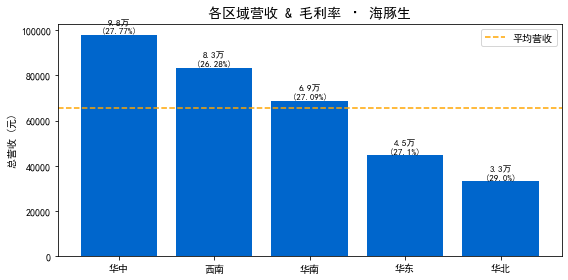

In [4]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(region_stats["region"], region_stats["总营收"], color="#0066CC")

# 在柱子上标注：营收(万) + 毛利率
for bar, (_, row) in zip(bars, region_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['总营收']/10000:.1f}万\n({row['毛利率(%)']}%)",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title("各区域营收 & 毛利率 · 海豚生", fontsize=14)
ax.set_ylabel("总营收 (元)")
ax.axhline(y=region_stats["总营收"].mean(), color="orange", linestyle="--", label="平均营收")
ax.legend()
plt.tight_layout()
plt.show()

---
## 第 4 步：写经营结论（今天最重要 ✏️）

用 **「数据发现 → 经营含义 → 下周动作」** 三段式，填进下面单元格：

In [6]:
# 第 4 步：根据区域汇总生成经营结论
BENCHMARK = 25.0

top_region = region_stats.iloc[0]
worst_region = region_stats.sort_values("毛利率(%)").iloc[0]
below_benchmark = region_stats[region_stats["毛利率(%)"] < BENCHMARK]

if len(below_benchmark) > 0:
    low_margin_regions = "、".join(below_benchmark["region"].tolist())
    low_margin_note = f"低于基准线 {BENCHMARK:.0f}% 的区域有：{low_margin_regions}。"
else:
    low_margin_note = f"所有区域的毛利率均达到或高于基准线 {BENCHMARK:.0f}%。"

my_report = f"""
【数据发现】
- 营收最高区域：{top_region['region']}区，营收 {top_region['总营收']/10000:.1f} 万，毛利率 {top_region['毛利率(%)']:.2f}%
- 毛利率最低区域：{worst_region['region']}区，毛利率 {worst_region['毛利率(%)']:.2f}%，{'低于' if worst_region['毛利率(%)'] < BENCHMARK else '高于'}基准 {BENCHMARK:.0f}%
- {low_margin_note}

【经营含义】
{worst_region['region']}区的毛利率相对较低，说明该区域可能存在低毛利客户、低毛利线路或报价偏低的问题；同时，{top_region['region']}区是当前营收主力，需要继续守住。

【下周动作 — 给区域经理的 2 条建议】
1. 针对 {worst_region['region']}区 的低毛利订单和客户，逐一排查价格、成本和线路结构。
2. 对比 {top_region['region']}区 与其他区域的产品组合，学习高毛利产品和高效率作业方式。
"""

print(my_report)


【数据发现】
- 营收最高区域：华中区，营收 9.8 万，毛利率 27.77%
- 毛利率最低区域：西南区，毛利率 26.28%，高于基准 25%
- 所有区域的毛利率均达到或高于基准线 25%。

【经营含义】
西南区的毛利率相对较低，说明该区域可能存在低毛利客户、低毛利线路或报价偏低的问题；同时，华中区是当前营收主力，需要继续守住。

【下周动作 — 给区域经理的 2 条建议】
1. 针对 西南区 的低毛利订单和客户，逐一排查价格、成本和线路结构。
2. 对比 华中区 与其他区域的产品组合，学习高毛利产品和高效率作业方式。



---
## 🎯 进阶小练习

自己写代码试试：

1. 哪个区域 **单量最多**？（提示：对 `总单量` 排序）
2. 算每个区域的 **平均单笔营收** = 总营收 / 总单量
3. 找出「营收前 2 但毛利率后 2」的区域（最有价值的经营问题）

<details>
<summary>💡 参考答案</summary>

```python
# 1. 单量最多
print(region_stats.sort_values("总单量", ascending=False).head(1))

# 2. 平均单笔营收
region_stats["平均单笔营收"] = (region_stats["总营收"] / region_stats["总单量"]).round(2)
print(region_stats[["region", "平均单笔营收"]])

# 3. 营收 TOP2 里毛利率最低的
top2 = region_stats.head(2)
print(top2.sort_values("毛利率(%)").iloc[0])
```
</details>

---

## ✅ Day 2 完成标准

- [ ] 跑通 `groupby` 区域汇总表
- [ ] 说出营收冠军 + 毛利率最低区域
- [ ] 写了 2 条可执行的经营建议
- [ ] （可选）柱状图画出来了

**预期结果参考：**
- 营收冠军：**华东区**（约 9.8 万）
- 毛利率最低：**华北区**（约 26.3%，仍高于 25% 基准）
- 本示例数据整体健康，练习重点是**分析框架**，不是找问题找问题

**明天 Day 3：** 客户 ABC 分层，找 TOP 客户 🚀

In [9]:
# 进阶小练习：直接计算结果
# 1. 单量最多的区域
most_orders_region = region_stats.sort_values("总单量", ascending=False).head(1)
print("单量最多的区域：")
print(most_orders_region[["region", "总单量"]])

# 2. 平均单笔营收
region_stats["平均单笔营收"] = (region_stats["总营收"] / region_stats["总单量"]).round(2)
print("\n各区域平均单笔营收：")
print(region_stats[["region", "平均单笔营收"]])

# 3. 营收前 2 但毛利率后 2 的区域
ranked_by_revenue = region_stats.sort_values("总营收", ascending=False)
top2 = ranked_by_revenue.head(2)
print("\n营收前 2 的区域：")
print(top2[["region", "总营收", "毛利率(%)"]])
print("\n营收前 2 中毛利率最低的区域：")
print(top2.sort_values("毛利率(%)").iloc[0])

单量最多的区域：
  region  总单量
3     华南   35

各区域平均单笔营收：
  region   平均单笔营收
1     华中  3265.52
4     西南  2528.48
3     华南  1967.00
0     华东  1537.03
2     华北  1442.32

营收前 2 的区域：
  region       总营收  毛利率(%)
1     华中  97965.64   27.77
4     西南  83439.89   26.28

营收前 2 中毛利率最低的区域：
region          西南
总营收       83439.89
总单量             33
总毛利       21928.79
毛利率(%)       26.28
平均单笔营收     2528.48
Name: 4, dtype: object
